In [1]:
import pandas as pd

df = pd.DataFrame({
    "temperature": [10, 7, 4, 0],
    "sales": [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [2]:
a = -4
b = 80

for i in range(len(df)):
    x = df.loc[i, "temperature"]
    y = df.loc[i, "sales"]
    pred = a * x + b
    error = y - pred

    print(f"X={x}, 실제값={y}, 예측값={pred}, 오차={pred}-{y}={error}")
    print("="*30)

X=10, 실제값=30, 예측값=40, 오차=40-30=-10
X=7, 실제값=50, 예측값=52, 오차=52-50=-2
X=4, 실제값=60, 예측값=64, 오차=64-60=-4
X=0, 실제값=80, 예측값=80, 오차=80-80=0


In [3]:
import torch

# x_tensor: 입력값 X(기온), y_tensor: 정답 Y(판매량)
x_tensor = torch.tensor(df["temperature"].values, dtype=torch.float32)
print(f"x_tensor = {x_tensor}")
y_tensor = torch.tensor(df["sales"].values, dtype=torch.float32)
print(f"y_tensor = {y_tensor}")

# a: 직선의 기울기, b: 직선의 절편
# requires_grad=True: PyTorch에게 이 값의 미분(Gradient) 계산하라고 알려 주는 설정
a = torch.tensor(-4.0, requires_grad=True)
print(a)
b = torch.tensor(80.0, requires_grad=True)
print(b)

learning_rate = 0.001       # 한번에 얼마나 크게 a, b를 수정할지 정하는 값(보폭)
epochs = 1000               # 전체 데이터를 몇 번 반복해서 학습할지 정하는 값
cost_history = []           # 매 epoch의 Cost를 저장할 리스트 (그래프로 그리기 위함)

# 학습 전후를 비교하려고, 시작 시점의 a, b와 Cost를 기억해 두기
initial_a = a.item()
initial_b = b.item()
with torch.no_grad():
    initial_cost = (torch.mean((y_tensor - (a * x_tensor + b)) ** 2)).item()
print(f"학습 전 a={initial_a:.4f}, b={initial_b:.4f}, Cost={initial_cost:.4f}")

x_tensor = tensor([10.,  7.,  4.,  0.])
y_tensor = tensor([30., 50., 60., 80.])
tensor(-4., requires_grad=True)
tensor(80., requires_grad=True)
학습 전 a=-4.0000, b=80.0000, Cost=30.0000


In [4]:
"""
for epoch in range(epochs):
    # pred: 현재 a, b로 계산한 예측값 (H(x) = a * x + b)
    pred = a * x_tensor + b

    # error는 기존 강의 정의 그대로 사용
    error = y_tensor - pred

    # cost: 현재 예측이 실제값과 얼마나 차이나는지 나타내는 Cost
    # Cost = 오차 제곱 평균
    cost = torch.mean(error ** 2)

    # cost.backward(): PyTorch가 a, b에 대한 Gradient를 자동으로 계산
    cost.backward()

    # a, b 값을 직접 수정할 때는 계산 그래프에 기록하지 않음
    with torch.no_grad():
        a -= learning_rate * a.grad # a.grad: PyTorch가 계산한 a의 Gradient
        b -= learning_rate * b.grad # b.grad: PyTorch가 계산한 b의 Gradient
    
    # PyTorch는 Gradient를 자동으로 누적하므로 매 epoch마다 초기화 필요
    a.grad.zero_()
    b.grad.zero_()

    cost_history.append(cost.item())

    if epoch % 100 == 0:
        print(f"epoch={epoch}, Cost={cost.item():.4f}, a={a.item():.4f}, b={b.item():.4f}")
    """

'\nfor epoch in range(epochs):\n    # pred: 현재 a, b로 계산한 예측값 (H(x) = a * x + b)\n    pred = a * x_tensor + b\n\n    # error는 기존 강의 정의 그대로 사용\n    error = y_tensor - pred\n\n    # cost: 현재 예측이 실제값과 얼마나 차이나는지 나타내는 Cost\n    # Cost = 오차 제곱 평균\n    cost = torch.mean(error ** 2)\n\n    # cost.backward(): PyTorch가 a, b에 대한 Gradient를 자동으로 계산\n    cost.backward()\n\n    # a, b 값을 직접 수정할 때는 계산 그래프에 기록하지 않음\n    with torch.no_grad():\n        a -= learning_rate * a.grad # a.grad: PyTorch가 계산한 a의 Gradient\n        b -= learning_rate * b.grad # b.grad: PyTorch가 계산한 b의 Gradient\n    \n    # PyTorch는 Gradient를 자동으로 누적하므로 매 epoch마다 초기화 필요\n    a.grad.zero_()\n    b.grad.zero_()\n\n    cost_history.append(cost.item())\n\n    if epoch % 100 == 0:\n        print(f"epoch={epoch}, Cost={cost.item():.4f}, a={a.item():.4f}, b={b.item():.4f}")\n    '

In [5]:
def run_gradient_descent(learning_rate, epochs):
    print(f"learning_rate={learning_rate}")
    global a, b
    for epoch in range(epochs):
        pred = a * x_tensor + b
        error = y_tensor - pred
        cost = torch.mean(error ** 2)
        cost.backward()
        with torch.no_grad():
            a -= learning_rate * a.grad # a.grad: PyTorch가 계산한 a의 Gradient
            b -= learning_rate * b.grad # b.grad: PyTorch가 계산한 b의 Gradient
        a.grad.zero_()
        b.grad.zero_()
        if cost.item() > 100000:
            print("Cost 가 너무 큽니다")
            print(f"cost={cost}, a={a}, b={b}, epoch={epoch}")
        if epoch % 100 == 0:
            print(f"epoch={epoch}, Cost={cost.item():.4f}, a={a.item():.4f}, b={b.item():.4f}")

In [6]:
run_gradient_descent(0.000001, 1000)

learning_rate=1e-06
epoch=0, Cost=30.0000, a=-4.0001, b=80.0000
epoch=100, Cost=29.5750, a=-4.0065, b=79.9992
epoch=200, Cost=29.1570, a=-4.0130, b=79.9985
epoch=300, Cost=28.7458, a=-4.0193, b=79.9977
epoch=400, Cost=28.3414, a=-4.0256, b=79.9969
epoch=500, Cost=27.9436, a=-4.0319, b=79.9962
epoch=600, Cost=27.5524, a=-4.0381, b=79.9954
epoch=700, Cost=27.1676, a=-4.0443, b=79.9947
epoch=800, Cost=26.7892, a=-4.0504, b=79.9939
epoch=900, Cost=26.4172, a=-4.0564, b=79.9931


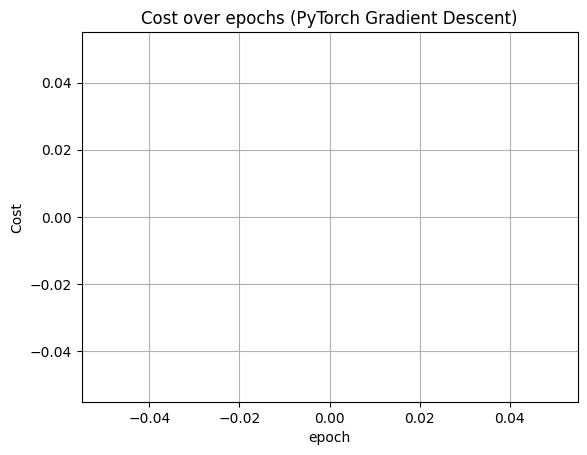

In [7]:
import matplotlib.pyplot as plt

plt.figure()        # 새 그래프 판 만들기
# x축 : epoch 번호(0, 1, 2, ...), y축 : 그 epoch의 Cost
# range(len(cost_history)) 는 0부터 저장된 Cost 개수만큼의 번호를 만들어 줍니다.
plt.plot(range(len(cost_history)), cost_history)
plt.title("Cost over epochs (PyTorch Gradient Descent)")    # 그래프 제목
plt.xlabel("epoch")     # x축 이름 : 반복 횟수
plt.ylabel("Cost")      # y축 이름 : Cost
plt.grid(True)          # 눈금선 표시
plt.show()              # 그래프 화면에 출력

In [8]:
# 학습 전 값: 12번 셀에서 학습 시작 전에 저장해 둔 initial_a, initial_b, initial_cost 를 사용합니다.
# 학습 후 값: 학습 반복문이 끝난 뒤 남아 있는 a, b 가 곧 학습된 값 (.item()으로 숫자 값을 꺼냄)
final_a = a.item()
final_b = b.item()
with torch.no_grad():
    final_cost = (torch.mean((y_tensor - (a * x_tensor + b)) ** 2)).item()

print("학습 전")
print(f"a = {initial_a:.4f}")
print(f"b = {initial_b:.4f}")
print(f"Cost = {initial_cost:.4f}")

print("\n학습 후")
print(f"a = {final_a:.4f}")
print(f"b = {final_b:.4f}")
print(f"Cost = {final_cost:.4f}")

학습 전
a = -4.0000
b = 80.0000
Cost = 30.0000

학습 후
a = -4.0624
b = 79.9924
Cost = 26.0513
